In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

## Cleaning and EDA

In [2]:
df = pd.read_csv("data/numerical_data.csv", index_col=0, parse_dates=True)

In [3]:
df.isna().sum()

Gold              0
DXY               0
Real_Yield_10Y    0
Breakeven_10Y     0
Fed_Funds         0
WTI_Oil           0
SP500             0
VIX               0
CPI_YoY           0
M2_YoY            0
dtype: int64

In [4]:
df["log_price"] = np.log(df["Gold"])
df["t"] = np.arange(len(df))

## Baseline Model

In [5]:
forecast_horizon = 325
start_index = len(df) - forecast_horizon - 1
WINDOW = 252*2

def fit_linear_trend(train_data):
    """Fit a linear trend model to log_price and return model + residuals."""
    X_trend = train_data[["t"]]
    y_trend = train_data["log_price"]

    trend_model = LinearRegression()
    trend_model.fit(X_trend, y_trend)

    train_data = train_data.copy()
    train_data["trend"] = trend_model.predict(X_trend)
    train_data["residual"] = train_data["log_price"] - train_data["trend"]

    return trend_model, train_data


def fit_arma_residual(train_data, p, d, q):
    """Fit an ARIMA model to the residuals and return the fitted model."""
    arma_model = ARIMA(train_data["residual"], order=(p, d, q))
    return arma_model.fit()


def forecast_next_day(trend_model, last_t):
    """Forecast the next day's gold price using trend + ARMA residual."""
    next_t = np.array([[last_t + 1]])
    trend_forecast = trend_model.predict(next_t)[0]
    #residual_forecast = arma_fitted.forecast(steps=1).iloc[0]

    log_price_forecast = trend_forecast #+ residual_forecast
    return np.exp(log_price_forecast)


def run_rolling_forecast(df, start_index, window=WINDOW):
    """
    Run a rolling window forecast over the dataframe.
    Training data is capped to the last `window` days at each step.

    Returns:
        dates, predictions, actuals — aligned lists for evaluation.
    """
    predictions, actuals, dates = [], [], []
    total = len(df) - start_index - 1

    for i in range(start_index, len(df) - 1):
        percent_complete = (i - start_index + 1) / total * 100
        print(f"\rProgress: {percent_complete:.2f}%", end="")

        train_data = df.iloc[max(0, i - window + 1):i + 1]  # last `window` days only

        trend_model, train_data = fit_linear_trend(train_data)
        #arma_fitted = fit_arma_residual(train_data, p, d, q)
        price_forecast = forecast_next_day(trend_model, train_data["t"].iloc[-1])

        predictions.append(price_forecast)
        actuals.append(df["Gold"].iloc[i + 1])
        dates.append(df.index[i + 1])

    print("\nDone!")
    return dates, predictions, actuals


# --- Usage ---
dates, predictions, actuals = run_rolling_forecast(df, start_index)

Progress: 100.00%
Done!


In [6]:
results = pd.DataFrame({
    "Date": dates,
    "Actual": actuals,
    "Predicted": predictions
}).set_index("Date")

In [7]:
results_2025 = results[results.index.year == 2025]
mape_2025 = (np.abs((results_2025["Actual"] - results_2025["Predicted"]) / results_2025["Actual"]).mean()) * 100
print(f"MAPE 2025: {mape_2025:.4f}%")

MAPE 2025: 5.1849%


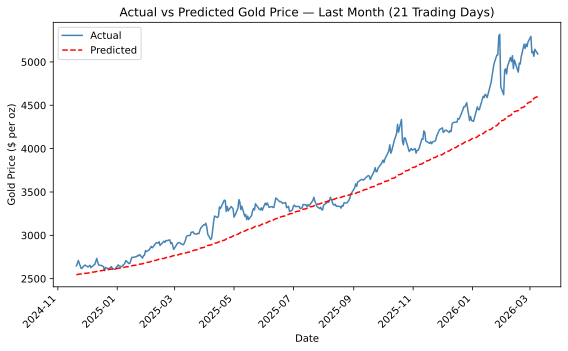

In [8]:
results_last_month = results.iloc[:]

plt.figure(figsize=(8, 5))
plt.plot(results_last_month.index, results_last_month["Actual"], color="steelblue", linewidth=1.5, label="Actual")
plt.plot(results_last_month.index, results_last_month["Predicted"], color="red", linewidth=1.5, linestyle="--", label="Predicted")
plt.title("Actual vs Predicted Gold Price — Last Month (21 Trading Days)")
plt.xlabel("Date")
plt.ylabel("Gold Price ($ per oz)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("results/p1_last_month_forecast_base", bbox_inches="tight")
plt.show()